# Unsupervised Learning
- 
- 

![](https://i.vas3k.blog/7w1.jpg)

- Unsupervised Learning is the type of ML in which:
    - Models learn from Unlabelled data
    - by finding hidden patterns or structures or groupings

Types:
1. Clustering -  find similar data and group it
2. Association Learning - find similar data from within the data
3. Dimensionality reduction - reduce the number of features while retaining the essential information

#### Clustering
- a technique to orgarize data into groups or clusters based on some hidden similarity/patterns
- Goals are: 
    - to find the natural grouping in data
    - simplify data by removing extra features, columns 

![](https://nickmccullum.com/images/python-machine-learning/introduction-k-means-clustering/k-means-clustering.png)

- **Hard Clustering** and **Soft Clustering**
    - each data point in exactly a single cluster - Hard
    - or can be part of other cluters too, overlaps too - Soft

![](https://tse3.mm.bing.net/th/id/OIP.G0ZMEt-AZiDopeeF4t_dHwHaDV?r=0&rs=1&pid=ImgDetMain&o=7&rm=3)


Algorithms used:
1. K-Means Clustering
2. Hierarchical Clustering
3. DBSCAN (Density Based Spatial Clustering of Applications with Noise)

### K-means Clustering
- 
- Resource 1 - https://neptune.ai/blog/k-means-clustering
- Resource 2 - https://www.pinecone.io/learn/k-means-clustering

![](https://miro.medium.com/v2/resize:fit:828/format:webp/1*rw8IUza1dbffBhiA4i0GNQ.png)

![](https://d138zd1ktt9iqe.cloudfront.net/media/seo_landing_files/centroid-formula-1620901411.png)

Steps to K-Means Clustering:

- you will have data
- you choose some K points i.e. number of clusters



1. **Initialization**: 
    - Randomly select K points as initial cluster centroids
    - You select three random points in the data or use **kmeans++** and initialize three points as spread out as possible
2. **Assignment**: 
    - Assign each data point to the nearest centroid.
    - Calculate distance of each data point to each of the cluster centroids and assign them to the nearest centroid
    - Distance is calculated using various metrics like:
        - euclidean, manhattan, minkowski

3. **Update**: 
    - Recalculate the centroids by averaging the points in each cluster
    - Centroid - is an average of the points in a group
    


4. **Convergence**: Repeat assignment and update steps until centroids stabilize.

Distance Metrics:

[Distance Metrics](https://www.geeksforgeeks.org/machine-learning/clustering-distance-measures/)

![](https://media.geeksforgeeks.org/wp-content/uploads/20241112152015029347/KNN_DISTANCES-660.jpg)


![](https://miro.medium.com/max/1200/1*FTVRr_Wqz-3_k6Mk6G4kew.png)

1. Euclidean:
    - Straight-line distance between two points 
2. Manhattan distance
    - total of the absolute differences between their Cartesian coordinates
    - sometimes referred to as the *L1 distance* or *city block* distance
3. 

The below illustration is from this blog - https://vas3k.com/blog/machine_learning/index.html

![](https://i.vas3k.blog/7w6.jpg)

Code implementation - 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [2]:
data = load_iris()
df = pd.DataFrame(data.data, columns = data.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [49]:
model_kmeans = KMeans(
    n_clusters = 2,
    init = 'random',
    random_state = 42
)

model_kmeans

,n_clusters,2
,init,'random'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [50]:
df['KClustering'] = model_kmeans.fit_predict(df)

In [51]:
# how far spread out the clusters are
# how good the model is
model_kmeans.inertia_

177.7202495543672

- Inertia is the sum of squared distances of each data point to its closest cluster center
- It's essentially the total squared error of the clustering.
- 

In [52]:
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),KClustering
60,5.0,2.0,3.5,1.0,1
67,5.8,2.7,4.1,1.0,1
57,4.9,2.4,3.3,1.0,1
68,6.2,2.2,4.5,1.5,1
121,5.6,2.8,4.9,2.0,1


#### Visualise data vs results

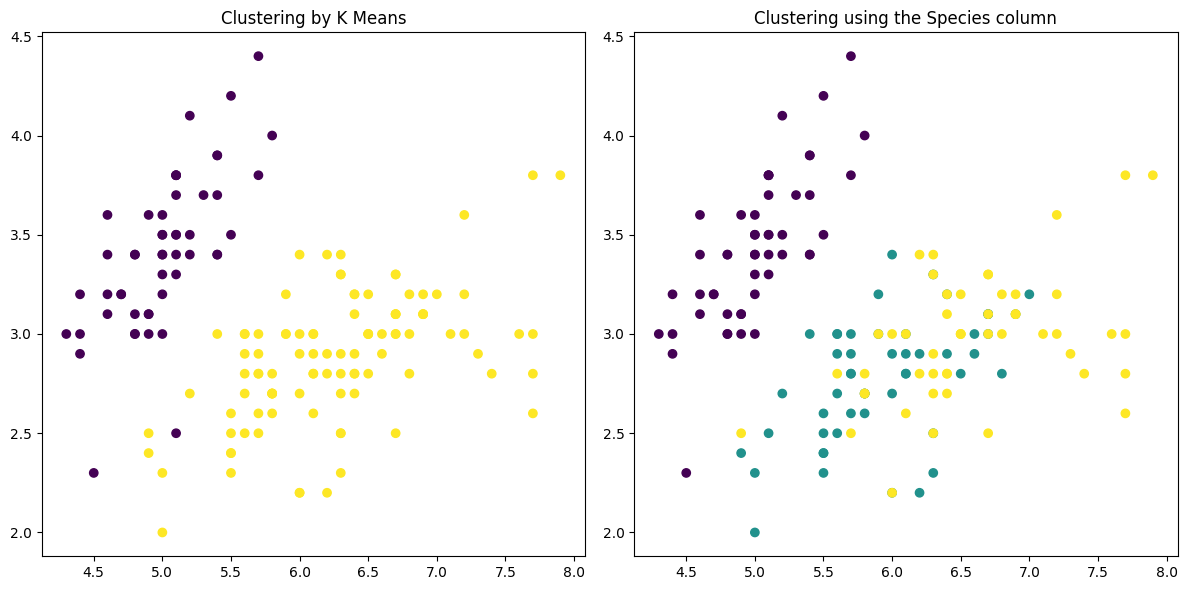

In [53]:
fig, ax = plt.subplots(1, 2, figsize = (12, 6))

ax[0].scatter(df['sepal length (cm)'], df['sepal width (cm)'], c = df['KClustering'])
ax[0].set_title('Clustering by K Means')


# from the dataset that I already have, we take the REAL species values
# let's see if Kmeans is doing good
ax[1].scatter(df['sepal length (cm)'], df['sepal width (cm)'], c = data.target)
ax[1].set_title('Clustering using the Species column')

plt.tight_layout()
plt.show()

### More about K Means
- Inititalization: 
    - Centroid initialization is the first and crucial step in clustering algorithms like K-Means. 
    - Poor initialization can lead to overlapping clusters, empty clusters, or slow convergence. 
    - The K-Means++ method: 
        - improves this step by strategically **spreading out** initial centroids instead of picking them purely at random
        - Keep them as far as possible from each other
        - the algorithm is more computationally expensive
        - but leads to faster convergence
- Convergence:
    - when all the centroids are at the optimal position

### Optimal value of K
- you don't know how many clusters there would be
- we use a couple of methods:
    - ELBOW Method

    - we use the WCSS (Within-Cluster Sum of Squares) error against the values of K
    - where ever there is a inflection point, that is our optimal value of K
    

In [ ]:
# Elbow Method

errors = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state= 42)
    kmeans.fit(df)
    errors.append(kmeans.inertia_)

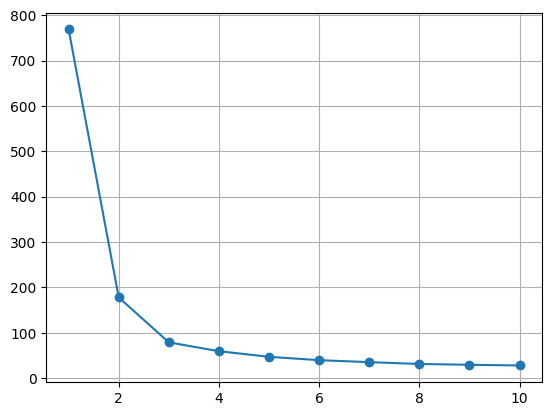

In [48]:
plt.plot(range(1,11), errors, marker = 'o')
plt.grid()
plt.show()